# Embedding Exploration

Sanity checks and visualizations for the three embedding spaces.

In [9]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import config

EMBEDDINGS_DIR = config.EMBEDDINGS_DIR

abstracts = np.load(os.path.join(EMBEDDINGS_DIR, "abstracts.npy"))
chunks    = np.load(os.path.join(EMBEDDINGS_DIR, "chunks.npy"))
captions  = np.load(os.path.join(EMBEDDINGS_DIR, "captions.npy"))

with open(os.path.join(EMBEDDINGS_DIR, "index.json")) as f:
    index = json.load(f)

print(f"Encoder model : {index.get('encoder_model', 'unknown')}")
print(f"abstracts.npy : {abstracts.shape}  ({abstracts.shape[0]} papers)")
print(f"chunks.npy    : {chunks.shape}  ({chunks.shape[0]} chunks)")
print(f"captions.npy  : {captions.shape}  ({captions.shape[0]} captions)")
print(f"Avg chunks/paper : {chunks.shape[0] / abstracts.shape[0]:.1f}")

Encoder model : unknown
abstracts.npy : (273, 384)  (273 papers)
chunks.npy    : (8358, 384)  (8358 chunks)
captions.npy  : (2686, 384)  (2686 captions)
Avg chunks/paper : 30.6


## Sanity checks

L2 norms should all be ~1.0 (unit vectors). Mean pairwise similarity gives a sense of how spread out the space is — lower is better for retrieval discrimination.

In [11]:
for name, mat in [("abstracts", abstracts), ("chunks", chunks), ("captions", captions)]:
    norms = np.linalg.norm(mat, axis=1)
    print(f"{name:10s}  norm min={norms.min():.4f}  max={norms.max():.4f}  mean={norms.mean():.4f}")

# Pairwise cosine similarity on a random 200-paper sample (full N^2 is slow)
rng = np.random.default_rng(42)
sample = abstracts[rng.choice(len(abstracts), size=min(200, len(abstracts)), replace=False)]
sim_matrix = sample @ sample.T
# Exclude diagonal (self-similarity = 1.0)
mask = ~np.eye(len(sample), dtype=bool)
print(f"\nAbstract pairwise cosine (off-diagonal sample):")
print(f"  mean={sim_matrix[mask].mean():.4f}  std={sim_matrix[mask].std():.4f}  max={sim_matrix[mask].max():.4f}")

abstracts   norm min=1.0000  max=1.0000  mean=1.0000
chunks      norm min=1.0000  max=1.0000  mean=1.0000
captions    norm min=1.0000  max=1.0000  mean=1.0000

Abstract pairwise cosine (off-diagonal sample):
  mean=0.2521  std=0.1176  max=0.7328


## 2D PCA scatter — abstract space

Projects all 273 abstract vectors to 2D using numpy SVD (same approach as `src/pca.py` will use). Each point is one paper. Spread and clusters here preview what the topic map will look like.

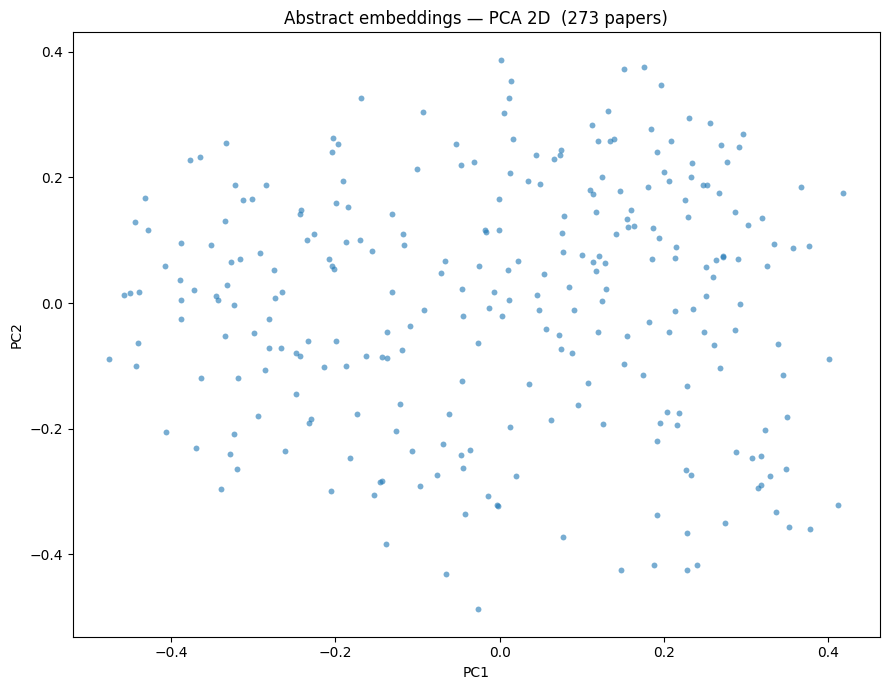

In [15]:
centered = abstracts - abstracts.mean(axis=0)
_, _, Vt = np.linalg.svd(centered, full_matrices=False)
coords_2d = centered @ Vt[:2].T   # (N, 2)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], s=18, alpha=0.6, linewidths=0)
ax.set_title(f"Abstract embeddings — PCA 2D  ({len(abstracts)} papers)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

## Cosine similarity distribution

Histogram of all pairwise similarities in the abstract space. A good retrieval space should have most pairs clustered near 0 with a long right tail for truly similar papers.

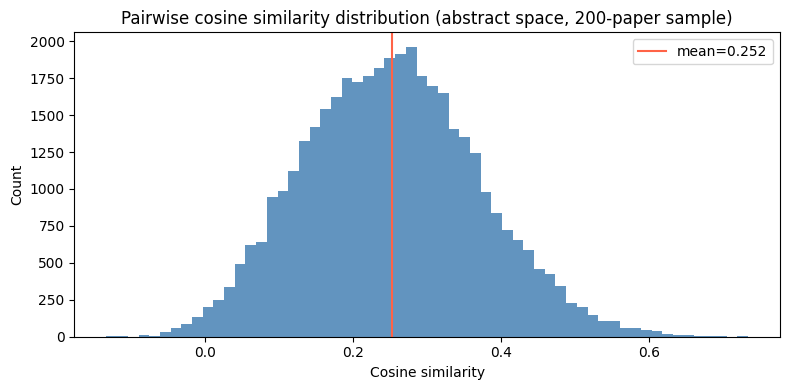

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sim_matrix[mask], bins=60, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(sim_matrix[mask].mean(), color="tomato", linewidth=1.5, label=f"mean={sim_matrix[mask].mean():.3f}")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Count")
ax.set_title("Pairwise cosine similarity distribution (abstract space, 200-paper sample)")
ax.legend()
plt.tight_layout()
plt.show()

## Query probe — nearest neighbors in abstract space

Encode a query and retrieve the top-k most similar abstracts. Change QUERY freely to test different retrieval scenarios.

In [1]:
import json, os, sys
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import config
from src.encoder import encode, load_model

if "abstracts" not in dir():
    abstracts = np.load(os.path.join(config.EMBEDDINGS_DIR, "abstracts.npy"))
if "index" not in dir():
    with open(os.path.join(config.EMBEDDINGS_DIR, "index.json")) as f:
        index = json.load(f)

# Load the model that was actually used to build the embeddings
encoder_model_name = index.get("encoder_model", config.ENCODER_MODEL_NAME)
print(f"Abstracts shape : {abstracts.shape}")
print(f"Encoder model   : {encoder_model_name}")
model = load_model(encoder_model_name)

QUERY = "efficient attention mechanisms for long-context transformers"  # edit freely
K = 5

query_vec = encode([QUERY], model)[0]
print(f"Query vec shape : {query_vec.shape}\n")

assert abstracts.shape[1] == query_vec.shape[0], (
    f"Dimension mismatch: abstracts are {abstracts.shape[1]}d but query is {query_vec.shape[0]}d. "
    f"The embeddings were built with a different model than '{encoder_model_name}'. "
    f"Check index.json encoder_model field and re-run build_embeddings.py --rebuild if needed."
)
scores = abstracts @ query_vec
top_k = np.argsort(scores)[::-1][:K]

abstract_ids = index["abstracts"]
print(f"Query: \"{QUERY}\"\n")
for rank, idx in enumerate(top_k, 1):
    paper_id = abstract_ids[idx]
    score    = scores[idx]
    title = next(
        (c["paper_title"] for c in index["chunks"] if c["paper_id"] == paper_id),
        paper_id,
    )
    print(f"  {rank}. [{score:.4f}]  {title}  ({paper_id})")

/Users/vrk93/PycharmProjects/CSCI473_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Abstracts shape : (273, 768)
Encoder model   : all-mpnet-base-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8295.07it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00,  4.87it/s]

Query vec shape : (768,)

Query: "efficient attention mechanisms for long-context transformers"

  1. [0.5874]  On-the-fly Repulsion in the Contextual Space for Rich Diversity in Diffusion Transformers  (2603.28762)
  2. [0.5767]  KVSculpt: KV Cache Compression as Distillation  (2603.27819)
  3. [0.5456]  Attention Frequency Modulation: Training-Free Spectral Modulation of Diffusion Cross-Attention  (2603.28114)
  4. [0.5384]  LongCat-Next: Lexicalizing Modalities as Discrete Tokens  (2603.27538)
  5. [0.5251]  HISA: Efficient Hierarchical Indexing for Fine-Grained Sparse Attention  (2603.28458)


## Chunk-level lookup for top paper

Given the top retrieved paper, show which chunks scored highest — this previews the second-stage finer-grained lookup that `retrieval.py` will implement.

In [5]:
import json, os, sys
from collections import defaultdict
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import config

if "abstracts" not in dir():
    abstracts = np.load(os.path.join(config.EMBEDDINGS_DIR, "abstracts.npy"))
if "chunks" not in dir():
    chunks = np.load(os.path.join(config.EMBEDDINGS_DIR, "chunks.npy"))
if "index" not in dir():
    with open(os.path.join(config.EMBEDDINGS_DIR, "index.json")) as f:
        index = json.load(f)
if "query_vec" not in dir():
    raise RuntimeError("Run the query probe cell first so query_vec and top_k are defined.")

top_paper_id = index["abstracts"][top_k[0]]

chunk_row_map = defaultdict(list)
for row, entry in enumerate(index["chunks"]):
    chunk_row_map[entry["paper_id"]].append(row)

paper_chunk_rows = chunk_row_map[top_paper_id]
paper_chunk_embs = chunks[paper_chunk_rows]
chunk_scores     = paper_chunk_embs @ query_vec

top_chunk_order = list(reversed(chunk_scores.argsort()))[:5]
print(f"Top chunks for: {top_paper_id}\n")
for rank, ci in enumerate(top_chunk_order, 1):
    row   = paper_chunk_rows[ci]
    entry = index["chunks"][row]
    score = chunk_scores[ci]
    heading = entry['heading']
    chunk_index = entry['chunk_index']
    snippet = entry['text'][:120].strip()
    print(f"  {rank}. [{score:.4f}]  {heading}  (chunk {chunk_index})")
    print(f"         {snippet}...")


Top chunks for: 2603.28762

  1. [0.6477]  3.1.Defining the Contextual Space  (chunk 0)
         The Contextual Space is the high-dimensional manifold formed within the Multimodal Attention (MM-Attention) blocks of a...
  2. [0.6020]  1.Introduction  (chunk 2)
         In this work, we present a novel approach that bypasses this trade-off by identifying and leveraging the Contextual Spac...
  3. [0.5876]  3.2.The Mechanism of Contextual Repulsion  (chunk 1)
         A critical advantage of our approach is that these forces are computed on-the-fly. Because we intervene directly on the...
  4. [0.5624]  3.2.The Mechanism of Contextual Repulsion  (chunk 0)
         We illustrate the positioning of our intervention in Figure 2(c) . Our key insight is that applying repulsion within the...
  5. [0.5610]  4.The Contextual Space  (chunk 0)
         In this section, we empirically examine the properties of the Contextual Space by analyzing how internal representations...


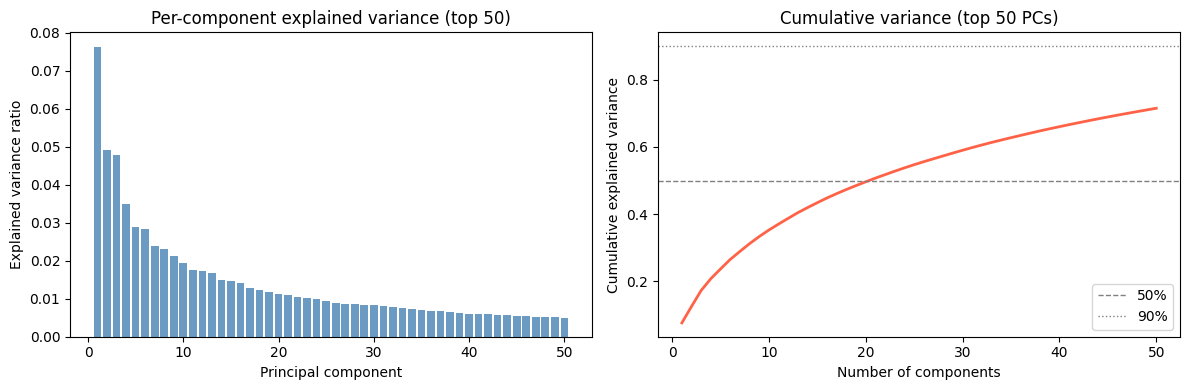

Components needed to explain 90% variance: 113
2 PCs explain: 12.5% of variance


In [3]:
import json, os, sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
import config

if "abstracts" not in dir():
    abstracts = np.load(os.path.join(config.EMBEDDINGS_DIR, "abstracts.npy"))

centered = abstracts - abstracts.mean(axis=0)
_, singular_values, _ = np.linalg.svd(centered, full_matrices=False)
explained_variance = singular_values**2 / (singular_values**2).sum()
cumulative = np.cumsum(explained_variance)

n_show = 50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n_show + 1), explained_variance[:n_show], color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Per-component explained variance (top 50)")

axes[1].plot(range(1, n_show + 1), cumulative[:n_show], color="tomato", linewidth=2)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="50%")
axes[1].axhline(0.9, color="gray", linestyle=":",  linewidth=1, label="90%")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance (top 50 PCs)")
axes[1].legend()

plt.tight_layout()
plt.show()

n_90 = int(np.searchsorted(cumulative, 0.9)) + 1
print(f"Components needed to explain 90% variance: {n_90}")
print(f"2 PCs explain: {cumulative[1]:.1%} of variance")